# Meta 2 ECAC - Testing Feature Selection Methods

In [1]:
# Importation of all Frameworks and Tools needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from scipy import stats


Importing Feature Dataset obtained in meta1

In [11]:
# Importing the dataset and filtering activities
df = pd.read_csv('feature_set.csv')
df_filtered = df[df["Activity"].isin(range(1, 8))].copy()
print(f"Filtered dataset shape: {df_filtered.shape}")
print(f"Unique activities after filtering: {df_filtered['Activity'].unique()}")


Filtered dataset shape: (1405, 179)
Unique activities after filtering: [1 2 3 4 5 6 7]


Checking whether the dataset is balanced or not 

C:\Users\ramya\AppData\Local\Temp\ipykernel_39896\3867902054.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y, palette="viridis")


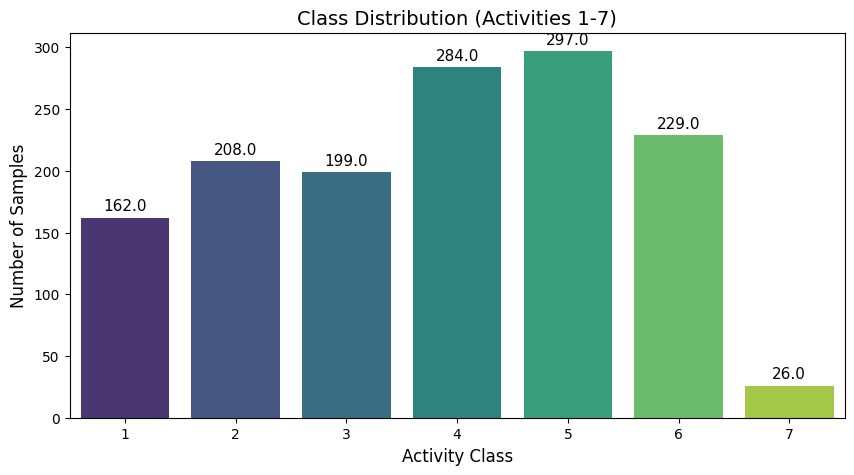


--- Exact Counts per Activity ---
Activity
1    162
2    208
3    199
4    284
5    297
6    229
7     26
Name: count, dtype: int64

Imbalance Ratio (Max/Min): 11.42


In [12]:
# Extract Labels (y)
y = df_filtered['Activity'].values
# Visualize Class Distribution
plt.figure(figsize=(10, 5))
# Use seaborn to plot count of each activity
ax = sns.countplot(x=y, palette="viridis")
plt.title('Class Distribution (Activities 1-7)', fontsize=14)
plt.xlabel('Activity Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()
# Numerical Summary
print("\n--- Exact Counts per Activity ---")
print(df_filtered['Activity'].value_counts().sort_index())

# Check for Imbalance
counts = df_filtered['Activity'].value_counts()
min_count = counts.min()
max_count = counts.max()
imbalance_ratio = max_count / min_count

print(f"\nImbalance Ratio (Max/Min): {imbalance_ratio:.2f}")